In [23]:
#Importation des bibliotheques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  

In [24]:
#Charger les donnees
data = pd.read_excel("fruits_dataset.xlsx")
print("Donnee chargees: ")
data.head(10)

Donnee chargees: 


,poids,diametre,couleur,fruit
0,189.934283,7.699678,0.266241,pomme
1,177.234714,7.462317,0.292774,pomme
2,192.953771,7.029815,0.260379,pomme
3,210.460597,6.676532,0.284602,pomme
4,175.316933,7.349112,0.205319,pomme
5,175.317261,7.196743,0.310665,pomme
6,211.584256,7.447597,0.300060,pomme
7,195.348695,7.317586,0.259146,pomme
8,170.610512,7.524776,0.332962,pomme
9,190.851201,6.732382,0.346879,pomme


In [25]:
#Separer les caracteristiques de la cible
X = data[['poids', 'diametre','couleur']]
y = data['fruit']

In [26]:
#Encoder les labels de la cible
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [27]:
#Separation des donnees en ensembles d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42)


In [28]:
#Entrainement du modele KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Precision du model KNN: 95.22

Rapport de classification:
              precision    recall  f1-score   support

      banane       1.00      1.00      1.00       296
      orange       0.92      0.94      0.93       291
       pomme       0.94      0.92      0.93       313

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



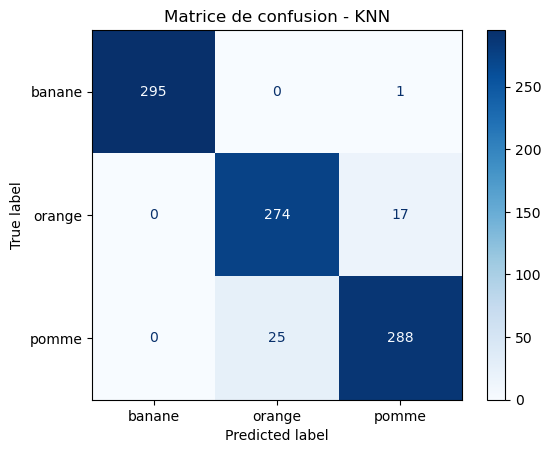

In [29]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precision du model KNN: {accuracy*100:.2f}\n")

print("Rapport de classification:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))
matrix = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=encoder.classes_)
display.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - KNN")
plt.show()

In [30]:
nouveau_fruit = np.array([[150, 7.5, 0.75]])
prediction = encoder.inverse_transform(model.predict(nouveau_fruit))
print(f"Le model KNN predit que le fruit est: {prediction[0]}")

Le model KNN predit que le fruit est: orange


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
